# Render an image of a slice of a neural SDF

## Create the grid

In [1]:
import torch

img_size = 1024

# Create a grid with coordinates (x, y, z)
x = torch.linspace(-1, 1, img_size)
y = torch.linspace(1, -1, img_size)

# Create the 2D grid using meshgrid
X, Y = torch.meshgrid(x, y, indexing='ij')

# Set constant Z coordinate
Z = torch.full_like(X, -0.1)  # Constant Z value of 2

# Combine x, y, z into a 3D tensor
grid = torch.stack((X, Y, Z), dim=-1)

# Linearize the 3D grid into a 1D tensor
points = grid.view(-1, 3)

points.shape

torch.Size([1048576, 3])

## Calculate the distances using the neural SDF (64x1)

In [2]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from i3d.util import from_pth

with torch.no_grad():

    model_64x1 = from_pth('data/bob_surface_1x64_w0-16.pth', device='cuda', w0=16)
    model_64x1 = model_64x1.cuda()

    # Assuming `points` is your grid of points from the previous step
    # Convert the numpy points to a PyTorch tensor
    points_tensor = torch.tensor(points, device='cuda', dtype=torch.float32)

    # If your model expects a batch dimension, add it
    points_tensor = points_tensor.unsqueeze(0)

    # Move the tensor to the same device as the model
    device = next(model_64x1.parameters()).device

    print(device)

    points_tensor = points_tensor.to(device)

    # Compute SDF values using the model

    model_output_64x1 = model_64x1(points_tensor)['model_out']

    # Process the output (e.g., remove batch dimension, move to CPU)
    sdf_values_neural_64x1 = model_output_64x1.squeeze(0).cpu().numpy()

    # Reshape the output to the grid shape
    sdf_values_neural_64x1 = sdf_values_neural_64x1.reshape(img_size, img_size).T

cuda:0


C:\Users\dsilva.vinicius\AppData\Local\Temp\ipykernel_8888\2568028139.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  points_tensor = torch.tensor(points, device='cuda', dtype=torch.float32)


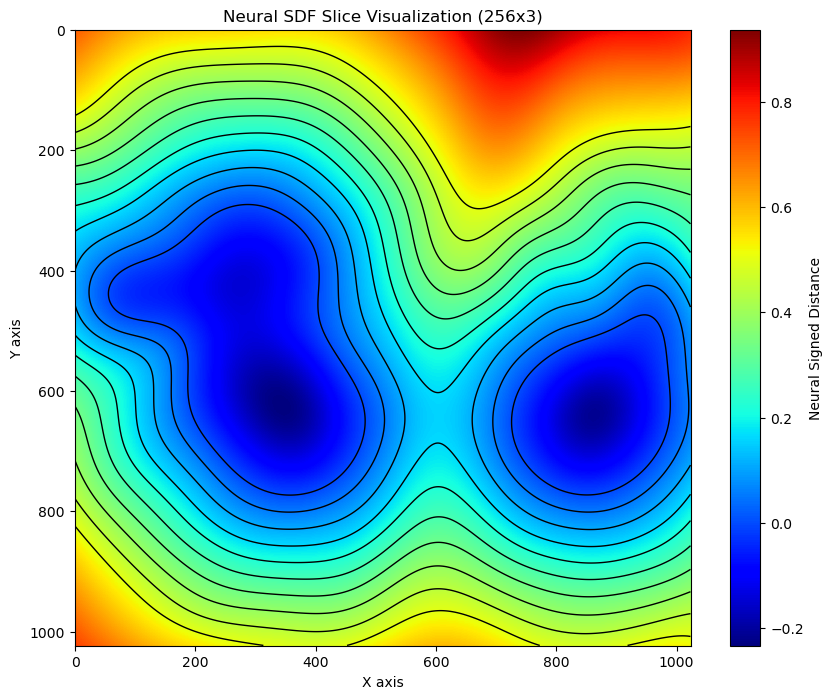

In [3]:
# Visualization
plt.figure(figsize=(10, 8))  # Width = 10 inches, Height = 8 inches
plt.imshow(sdf_values_neural_64x1, cmap='jet', interpolation='nearest')
plt.colorbar(label='Neural Signed Distance')

# Add contour lines to emphasize changes in distances
contour_levels = np.linspace(0.0, 0.5, 10)  # Define contour levels
plt.contour(sdf_values_neural_64x1, contour_levels, colors='black', linewidths=1.0)  # Add contours

# Set an appropriate aspect ratio
plt.gca().set_aspect('equal', adjustable='box')  # Keep aspect ratio as 1:1

plt.title('Neural SDF Slice Visualization (256x3)')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

## SDF Neiborhood

In [ ]:
sdf_neigh_values = sdf_values_neural_64x1
size = 100000000000
power = 8
sdf_neigh_values[:, :] = sdf_neigh_values[:, :] * (np.exp(-size * sdf_values_neural_64x1 ** power)) + (1-np.exp(-size * sdf_values_neural_64x1 ** power))

# Visualization
plt.figure(figsize=(10, 8))  # Width = 10 inches, Height = 8 inches
plt.imshow(sdf_neigh_values, cmap='jet', interpolation='nearest')
plt.colorbar(label='Neural Signed Distance')

# Add contour lines to emphasize changes in distances
contour_levels = np.linspace(0.0, 0.5, 10)  # Define contour levels
plt.contour(sdf_neigh_values, contour_levels, colors='black', linewidths=1.0)  # Add contours

# Set an appropriate aspect ratio
plt.gca().set_aspect('equal', adjustable='box')  # Keep aspect ratio as 1:1

plt.title('Neural SDF Neighborhood Slice Visualization')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

## Normals

C:\Users\dsilva.vinicius\AppData\Local\Temp\ipykernel_8888\4176377842.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  points_tensor_with_grad = torch.tensor(points, device='cuda', dtype=torch.float32, requires_grad=True)


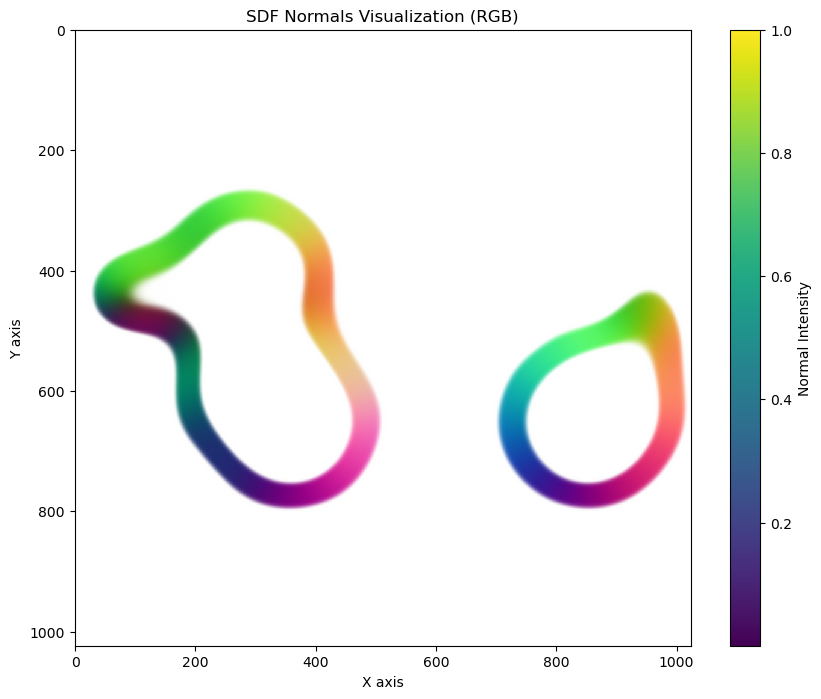

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Define a function to compute the gradient of the SDF
def compute_normals(model, points_tensor_with_grad):
    # Compute SDF values using the model
    model_output = model(points_tensor_with_grad, preserve_grad=True)['model_out']

    # Compute gradients with respect to the input points
    sdf_gradients = torch.autograd.grad(outputs=model_output, inputs=points_tensor_with_grad,
                                        grad_outputs=torch.ones_like(model_output),
                                        create_graph=True, retain_graph=True)[0]

    # Normalize the gradients to get the unit normal vectors
    sdf_normals = sdf_gradients / (sdf_gradients.norm(dim=-1, keepdim=True) + 1e-10)  # Avoid division by zero

    return sdf_normals

# Convert the numpy points to a PyTorch tensor
points_tensor_with_grad = torch.tensor(points, device='cuda', dtype=torch.float32, requires_grad=True)

# Compute normals
sdf_normals_neural_64x1 = compute_normals(model_64x1, points_tensor_with_grad)

# Process the output (e.g., remove batch dimension, move to CPU)
sdf_normals_neural_64x1 = sdf_normals_neural_64x1.cpu().detach().numpy()

# Reshape the normals to the grid shape
sdf_normals_neural_64x1 = sdf_normals_neural_64x1.reshape(img_size, img_size, 3).transpose(1, 0, 2)

# Normalize the normal vectors to [0, 1] range for visualization
normals_visualization = (sdf_normals_neural_64x1 - sdf_normals_neural_64x1.min()) / (sdf_normals_neural_64x1.max() - sdf_normals_neural_64x1.min())

size = 100000000000
power = 8
normals_visualization[:, :, 0] = normals_visualization[:, :, 0] * (np.exp(-size * sdf_values_neural_64x1 ** power)) + (1-np.exp(-size * sdf_values_neural_64x1 ** power))
normals_visualization[:, :, 1] = normals_visualization[:, :, 1] * (np.exp(-size * sdf_values_neural_64x1 ** power)) + (1-np.exp(-size * sdf_values_neural_64x1 ** power))
normals_visualization[:, :, 2] = normals_visualization[:, :, 2] * (np.exp(-size * sdf_values_neural_64x1 ** power)) + (1-np.exp(-size * sdf_values_neural_64x1 ** power))

# Visualization
plt.figure(figsize=(10, 8))
plt.imshow(normals_visualization, interpolation='nearest')
plt.colorbar(label='Normal Intensity')

plt.title('SDF Normals Visualization (RGB)')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.gca().set_aspect('equal', adjustable='box')  # Keep aspect ratio as 1:1
plt.show()

## Texture

In [ ]:
with torch.no_grad():

    model_tex = from_pth('data/bob_texture_w0-60.pth', device='cuda', w0=60)
    model_tex = model_tex.cuda()

    # Assuming `points` is your grid of points from the previous step
    # Convert the numpy points to a PyTorch tensor
    points_tensor = torch.tensor(points, device='cuda', dtype=torch.float32)

    # If your model expects a batch dimension, add it
    points_tensor = points_tensor.unsqueeze(0)

    # Move the tensor to the same device as the model
    device = next(model_tex.parameters()).device

    print(device)

    points_tensor = points_tensor.to(device)

    # Compute SDF values using the model

    model_output_tex = model_tex(points_tensor)['model_out']

    # Process the output (e.g., remove batch dimension, move to CPU)
    tex_values_neural = model_output_tex.squeeze(0).cpu().numpy()

    # Reshape the output to the grid shape
    tex_values_neural = tex_values_neural.reshape(img_size, img_size, 3).transpose((1, 0, 2))

    size = 100000000000
    power = 8
    tex_values_neural[:, :, 0] = tex_values_neural[:, :, 0] * (np.exp(-size * sdf_values_neural_64x1 ** power)) + (1-np.exp(-size * sdf_values_neural_64x1 ** power))
    tex_values_neural[:, :, 1] = tex_values_neural[:, :, 1] * (np.exp(-size * sdf_values_neural_64x1 ** power)) + (1-np.exp(-size * sdf_values_neural_64x1 ** power))
    tex_values_neural[:, :, 2] = tex_values_neural[:, :, 2] * (np.exp(-size * sdf_values_neural_64x1 ** power)) + (1-np.exp(-size * sdf_values_neural_64x1 ** power))

C:\Users\dsilva.vinicius\AppData\Local\Temp\ipykernel_7484\3880994502.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  points_tensor = torch.tensor(points, device='cuda', dtype=torch.float32)


cuda:0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


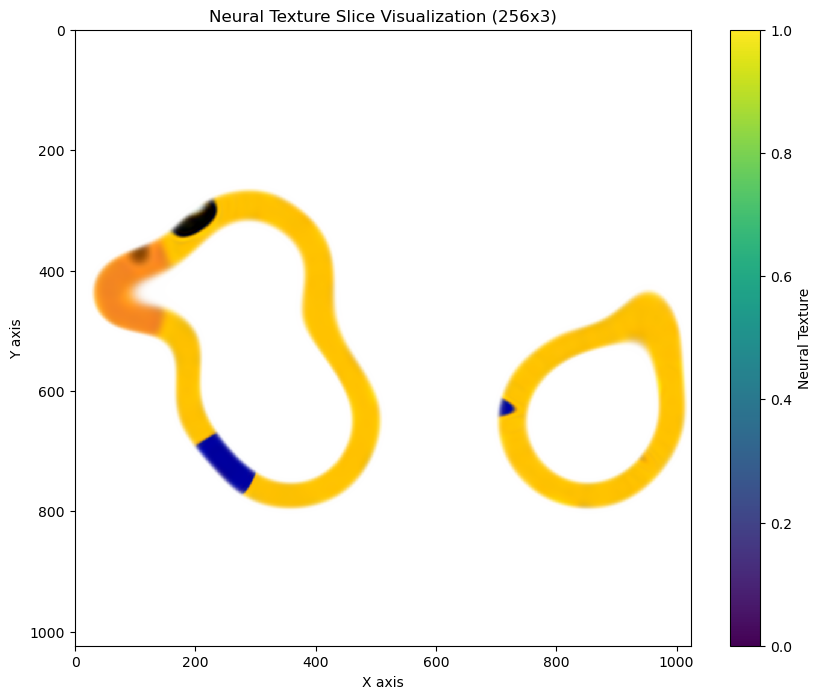

In [ ]:
# Visualization
plt.figure(figsize=(10, 8))  # Width = 10 inches, Height = 8 inches
plt.imshow(tex_values_neural, interpolation='nearest')
plt.colorbar(label='Neural Texture')

# Add contour lines to emphasize changes in distances
#contour_levels = np.linspace(0.0, 0.5, 10)  # Define contour levels
#plt.contour(sdf_values_neural_64x1, contour_levels, colors='black', linewidths=1.0)  # Add contours

# Set an appropriate aspect ratio
plt.gca().set_aspect('equal', adjustable='box')  # Keep aspect ratio as 1:1

plt.title('Neural Texture Slice Visualization (256x3)')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()